# Correct A Reconstruction

Sometimes a reconstruction is usable, but a few details still need cleaning before analysis. In this tutorial, you will look for three common problems: a very small diameter, a sudden jump in z, and shrinkage that changes the shape of the reconstruction.

## Workflow

```text
sample SWC files
      |
      v
find a suspicious diameter
      |
      v
view and correct the node
      |
      v
find and correct a z-jump
      |
      v
inspect and correct shrinkage
```

## Reading the correction commands

The pattern is the same each time: first find or inspect the problem, then write a corrected copy.

| Part | Meaning |
| --- | --- |
| `swc find` | find nodes that match a condition |
| `-d 0.1 --comp lt` | find diameters smaller than `0.1` um |
| `-z 10` | find z-jumps larger than `10` um |
| `swc repair -d node-ids` | correct diameters at selected nodes |
| `swc repair -z node-ids --zjump join` | correct selected z-jumps |
| `-k 1.25 -kxy 1.1` | correct shrinkage in z and xy |
| `-o output/file.swc` | save the corrected file |

## Command helper

Run this cell once before the tutorial commands. It creates `shell_cmd()`, a small notebook helper that runs terminal commands, shows their output, and displays images when a command creates one.

In [1]:
import subprocess
from pathlib import Path

from IPython.display import Image, display


def shell_cmd(command, image=None):
    print("Executed command:")
    print(command)
    result = subprocess.run(
        command,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    output = result.stdout.rstrip()
    print("\nOutput:")
    print(output if output else "(empty)", end="\n\n")

    if image is not None and Path(image).exists():
        display(Image(filename=image))

## Copy sample files

Use a simple branch for diameter correction, a small file with a z-jump, and an NMO reconstruction for shrinkage correction.

In [2]:
shell_cmd("cp -v ../tests/data/pass_simple_branch.swc data/")
shell_cmd("cp -v ../tests/data/pass_zjump.swc data/")
shell_cmd("cp -v ../tests/data/pass_nmo_3_cut.swc data/")

Executed command:
cp -v ../tests/data/pass_simple_branch.swc data/

Output:
'../tests/data/pass_simple_branch.swc' -> 'data/pass_simple_branch.swc'

Executed command:
cp -v ../tests/data/pass_zjump.swc data/

Output:
'../tests/data/pass_zjump.swc' -> 'data/pass_zjump.swc'

Executed command:
cp -v ../tests/data/pass_nmo_3_cut.swc data/

Output:
'../tests/data/pass_nmo_3_cut.swc' -> 'data/pass_nmo_3_cut.swc'



## Find a small diameter

Find basal dendrite nodes with diameter smaller than 0.1 μm (`-d 0.1 --comp lt`). This is node 5 in the example.

In [3]:
shell_cmd("swc find data/pass_simple_branch.swc -p 3 -d 0.1 --comp lt")

Executed command:
swc find data/pass_simple_branch.swc -p 3 -d 0.1 --comp lt

Output:
5



## Check where it is

Mark the node before correcting it.

Executed command:
swc view data/pass_simple_branch.swc -j xy -m 5 --show-id --no-axes -o output/small_diameter.png

Output:
(empty)



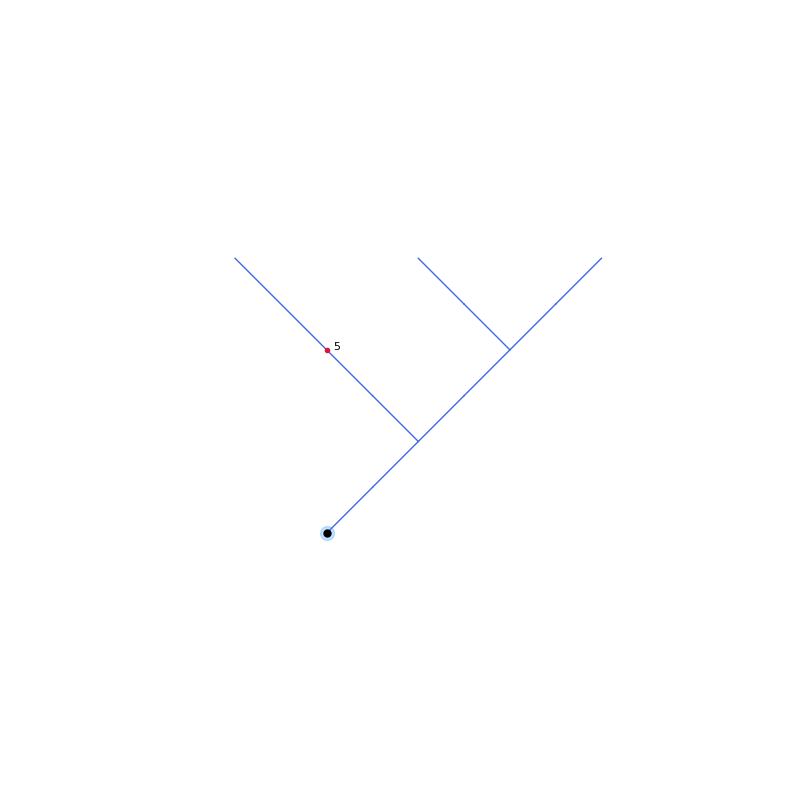

In [4]:
shell_cmd(
    "swc view data/pass_simple_branch.swc -j xy -m 5 --show-id --no-axes -o output/small_diameter.png",
    image="output/small_diameter.png",
)

## Correct the diameter

Use the same node ID to correct the diameter (option `-d` in `repair` command) and save the result.

In [5]:
shell_cmd("swc repair data/pass_simple_branch.swc -d 5 -o output/fixdiam.swc")

Executed command:
swc repair data/pass_simple_branch.swc -d 5 -o output/fixdiam.swc

Output:
(empty)



The radius of node 5 in the file `fixdiam.swc` should now be similar to its neighbors, nodes 4 and 6.

## Find a z-jump

A z-jump is a sudden shift of the reconstruction along the z-axis. This example finds a jump greater than 10 μm (`-z 10`) and reports problematic node's ID (i.e., node 4 here).

Executed command:
swc find data/pass_zjump.swc -z 10

Output:
4

Executed command:
swc view data/pass_zjump.swc -m 4 -m 2 3 5 --show-id --no-axes --scale 20 -o output/zjump_points.png

Output:
(empty)



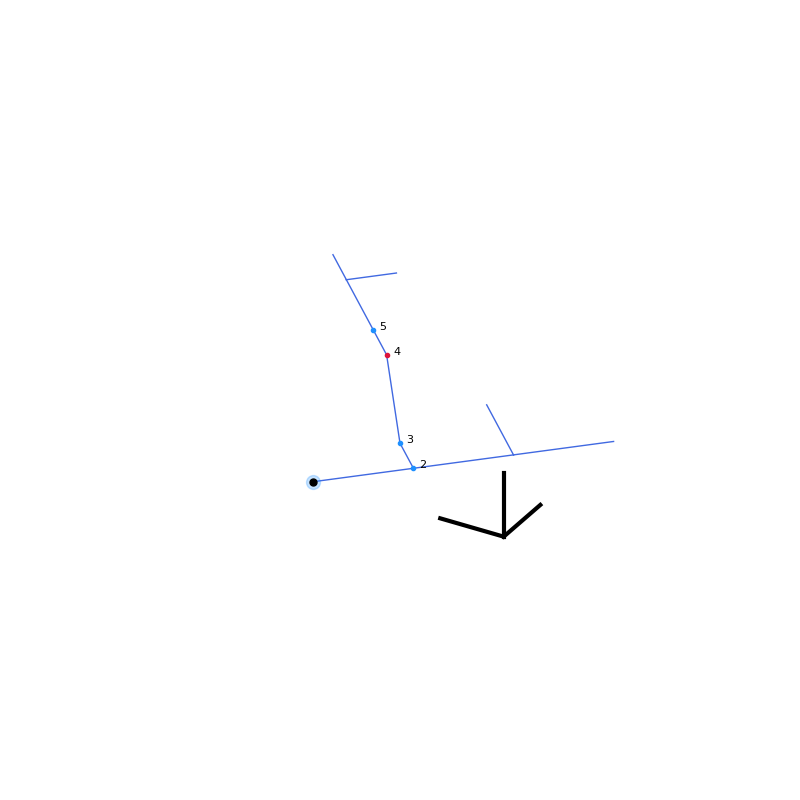

In [6]:
shell_cmd("swc find data/pass_zjump.swc -z 10")
shell_cmd(
    "swc view data/pass_zjump.swc -m 4 -m 2 3 5 --show-id --no-axes --scale 20 -o output/zjump_points.png",
    image="output/zjump_points.png",
)

Note the jump from node 3 to node 4 along the vertical axis.

## Correct the z-jump

This example uses correction method *join* (`--zjump join`). Other options are described in the documentation.

Executed command:
swc repair data/pass_zjump.swc -z 4 --zjump join -o output/fixzjump.swc

Output:
(empty)

Executed command:
swc view output/fixzjump.swc data/pass_zjump.swc -c shadow --no-axes -o output/zjump_corrected.png

Output:
(empty)



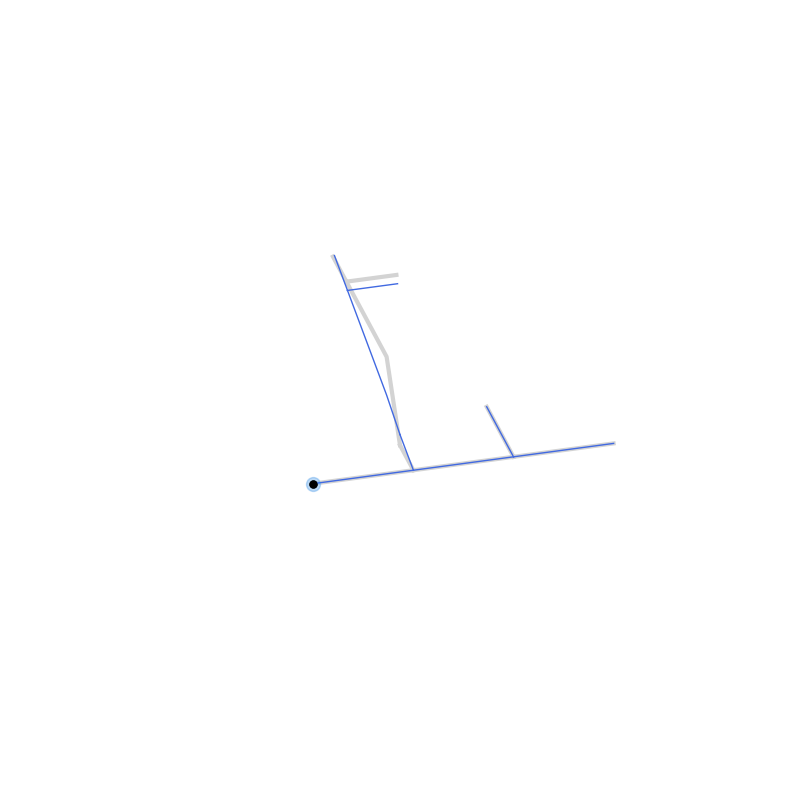

In [7]:
shell_cmd("swc repair data/pass_zjump.swc -z 4 --zjump join -o output/fixzjump.swc")
shell_cmd(
    "swc view output/fixzjump.swc data/pass_zjump.swc -c shadow --no-axes -o output/zjump_corrected.png",
    image="output/zjump_corrected.png",
)

## Inspect shrinkage

Start by viewing the reconstruction from the side.

Executed command:
swc view data/pass_nmo_3_cut.swc -j xz -o output/shrink_before.png

Output:
(empty)



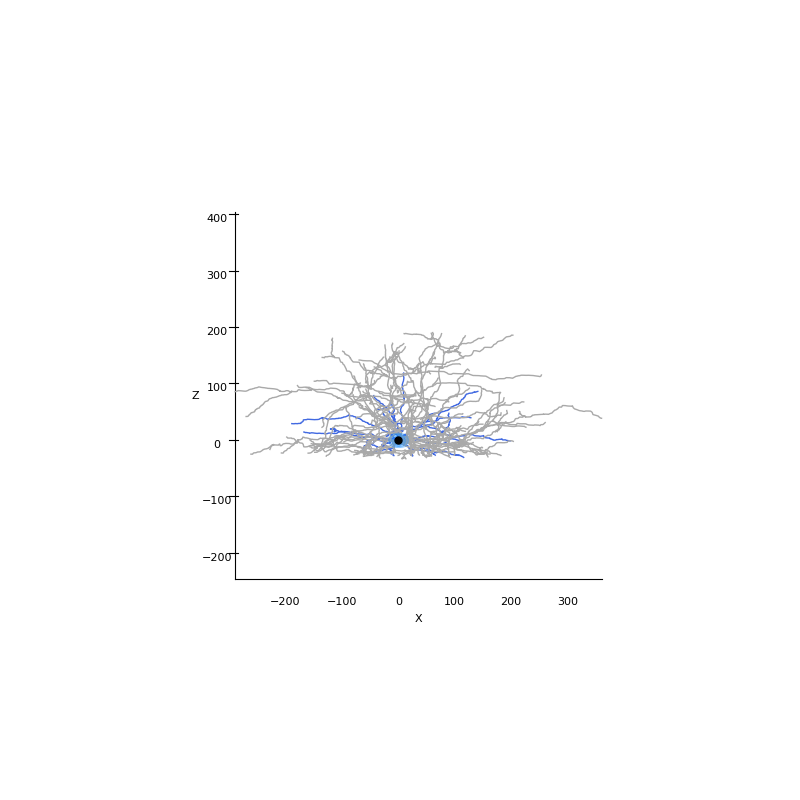

In [8]:
shell_cmd(
    "swc view data/pass_nmo_3_cut.swc -j xz -o output/shrink_before.png",
    image="output/shrink_before.png",
)

Note the compression of the neurites close to the slice surface at the bottom.

## Correct shrinkage

Apply correction factor 1.25 in the z-axis and 1.1 in x-y (or other shrinkage values reported for the reconstruction).

Executed command:
swc repair data/pass_nmo_3_cut.swc -k 1.25 -kxy 1.1 --bottom-up -o output/fixshrink.swc

Output:
(empty)

Executed command:
swc view output/fixshrink.swc data/pass_nmo_3_cut.swc -p 2 3 -j xz -c cells -o output/shrink_compare.png

Output:
(empty)



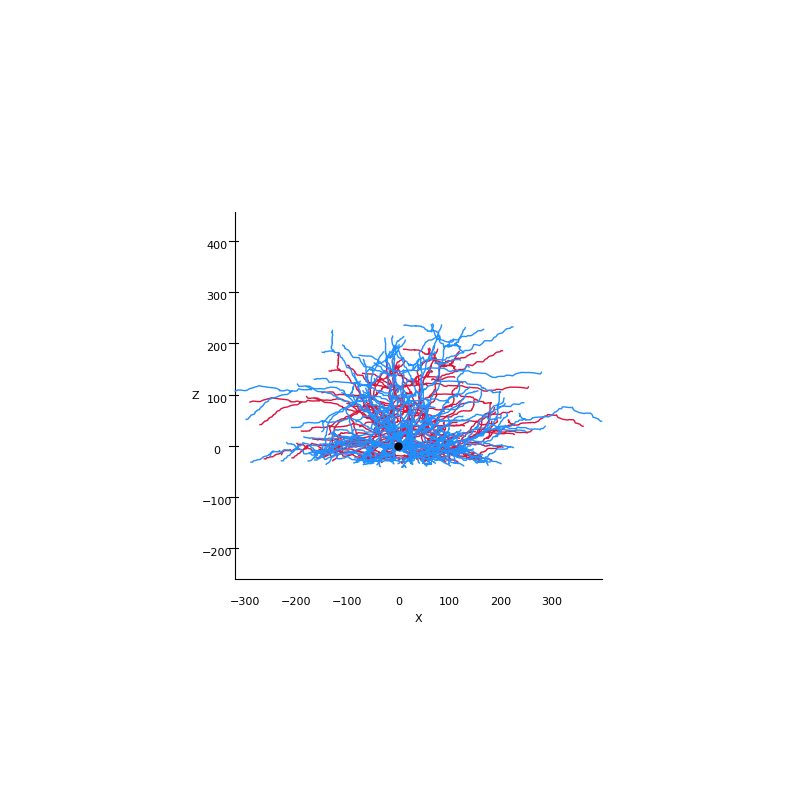

In [9]:
shell_cmd("swc repair data/pass_nmo_3_cut.swc -k 1.25 -kxy 1.1 --bottom-up -o output/fixshrink.swc")
shell_cmd(
    "swc view output/fixshrink.swc data/pass_nmo_3_cut.swc -p 2 3 -j xz -c cells -o output/shrink_compare.png",
    image="output/shrink_compare.png",
)